### Crear grid con resolución cualquiera

Ya que se tienen los datos filtrados, vamos a meterlos a un grid, para ver (el número de) perfiles por latitud y longitud, y así hacer la media para cada perfil de la temperatura entre 4000 y 5000 metros, y junto a los tiempos de las medidas, hacer mínimos cuadrados para hallar la tendencias de temperaturas.

Importamos los paquetes

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import datetime as datetime
import pandas as pd
import xarray as xr
from tqdm import tqdm
import cartopy
import cartopy.feature as cfeature
import cartopy.crs as ccrs
from grid import *

Abrimos el dataset de los datos filtrados, y se quitan de la tabla todos los valores en las que la presión esté fuera del intervalo [4000, 5000].

In [5]:
path = "./Data/join/total_filt.nc"
ds = xr.open_dataset(path)
ds = ds.where((ds.pressure <= 5000) & (ds.pressure >= 4000), drop = True)

In [6]:
# Filtramos en el rango entre 1990-2010
date_ini  = pd.to_datetime('1990-01-01')
date_end = pd.to_datetime('2010-12-31') 
ds = ds.where((ds.time >= date_ini) & (ds.time <= date_end), drop = True)

In [7]:
times = ds.time.values.astype("datetime64[D]").astype(float) # Tiempo en días
ds["time_days"] = (["N_PROF"], times)


Buscamos que perfiles no tienen valores Nan

In [8]:
temp = ds.ctd_temperature_filt
idxs = []
for idx in range(temp.shape[0]):
    temp_i = temp[idx].values
    nans = np.isnan(temp_i)
    temp_i = temp_i[nans == True]
    if len(temp_i) == 0:
        idxs.append(idx)

Nuestros espacios de longitud y latitud van a ser arrays de tamaño $n_{lon}$ y $n_{lat}$, con un cierto step $\Delta l$, que se refiere a la resolución que el usuario quiera dar. El parámetro depth $d$, nos va a indicar la profundidad que van a tener los arrays de nº de perfiles, perfiles, temperaturas y tiempos, es decir, el máximo número de perfiles que va a haber en una coordenada. Se ha usado $d = 100 \Delta l$, de forma que se tienen los arrays:

$n \in \mathbb{R}^{n_{lat} \times n_{lon}}$

$profiles \in \mathbb{R}^{n_{lat} \times n_{lon} \times d}$

$t_{means} \in \mathbb{R}^{n_{lat} \times n_{lon} \times d}$

$times \in \mathbb{R}^{n_{lat} \times n_{lon} \times d}$

In [9]:
step = 1
depth = int(step * 100)
longitude_space = np.arange(-180, 180 + step, step, dtype = float)
latitude_space = np.arange(-90, 90 + step, step, dtype = float)
pressure_max = np.max(ds.pressure.values) + 1
p_resolution = 100

In [10]:
ds

<xarray.Dataset> Size: 334MB
Dimensions:               (N_PROF: 13725, P: 1001)
Coordinates:
    time                  (N_PROF) datetime64[ns] 110kB 1991-09-05T13:46:00 ....
    section_id            (N_PROF) <U40 2MB './Data/corrected_sections_filtra...
    file_name             (N_PROF) <U29 2MB '1991_06MT18_1_ctd.nc' ... '2008_...
    latitude              (N_PROF) float64 110kB 60.0 59.97 ... -44.12 -44.05
    longitude             (N_PROF) float64 110kB -42.51 -42.17 ... 146.2 146.3
    pressure              (P) int64 8kB 4000 4001 4002 4003 ... 4998 4999 5000
Dimensions without coordinates: N_PROF, P
Data variables:
    ctd_temperature_filt  (N_PROF, P) float64 110MB nan nan nan ... nan nan nan
    ctd_salinity_filt     (N_PROF, P) float64 110MB nan nan nan ... nan nan nan
    ctd_oxygen_filt       (N_PROF, P) float64 110MB nan nan nan ... nan nan nan
    time_days             (N_PROF) float64 110kB 7.917e+03 ... 1.398e+04

Del script *grid.py* se llama a la función *occupation_matrix*,  que dado un set de datos, los espacios de longitud y latitud, y profundidad, devuelve los arrays mencionados anteriormente.

In [11]:
n, profiles, t_means, sal_means, times = occupation_matrix(ds, profile_idxs = idxs, latitudes = latitude_space, longitudes = longitude_space, depth = depth, p_resolution = p_resolution)

Por último, guardamos el set de datos en *profiles.nc*

In [12]:
profiles_ds = xr.Dataset(
    data_vars = dict(
        profiles = (["latitude", "longitude", "depth"], profiles),
        t_means = (["latitude", "longitude", "depth"], t_means),
        sal_means = (["latitude", "longitude", "depth"], t_means),
        n = (["latitude", "longitude"], n)
    ),
    coords = dict(
        latitude = (["latitude"], latitude_space),
        longitude = (["longitude"], longitude_space),
        depth = (["depth"], np.arange(0, depth)),
        #levels = (["levels"], [4000 + p for p in np.arange(ds.P.values[1], ds.P.values[-1], p_resolution, dtype = int)]),
        times = (["latitude", "longitude", "depth"], times)
    )
)

profiles_ds.to_netcdf("./Data/grid/grid_1_9010.nc")

In [13]:
ds=profiles_ds

In [14]:
ds.where(ds.longitude == -103, drop = True).where(ds.n > 0, drop = True).latitude.values

array([-65., -64., -63., -62., -61., -60.])

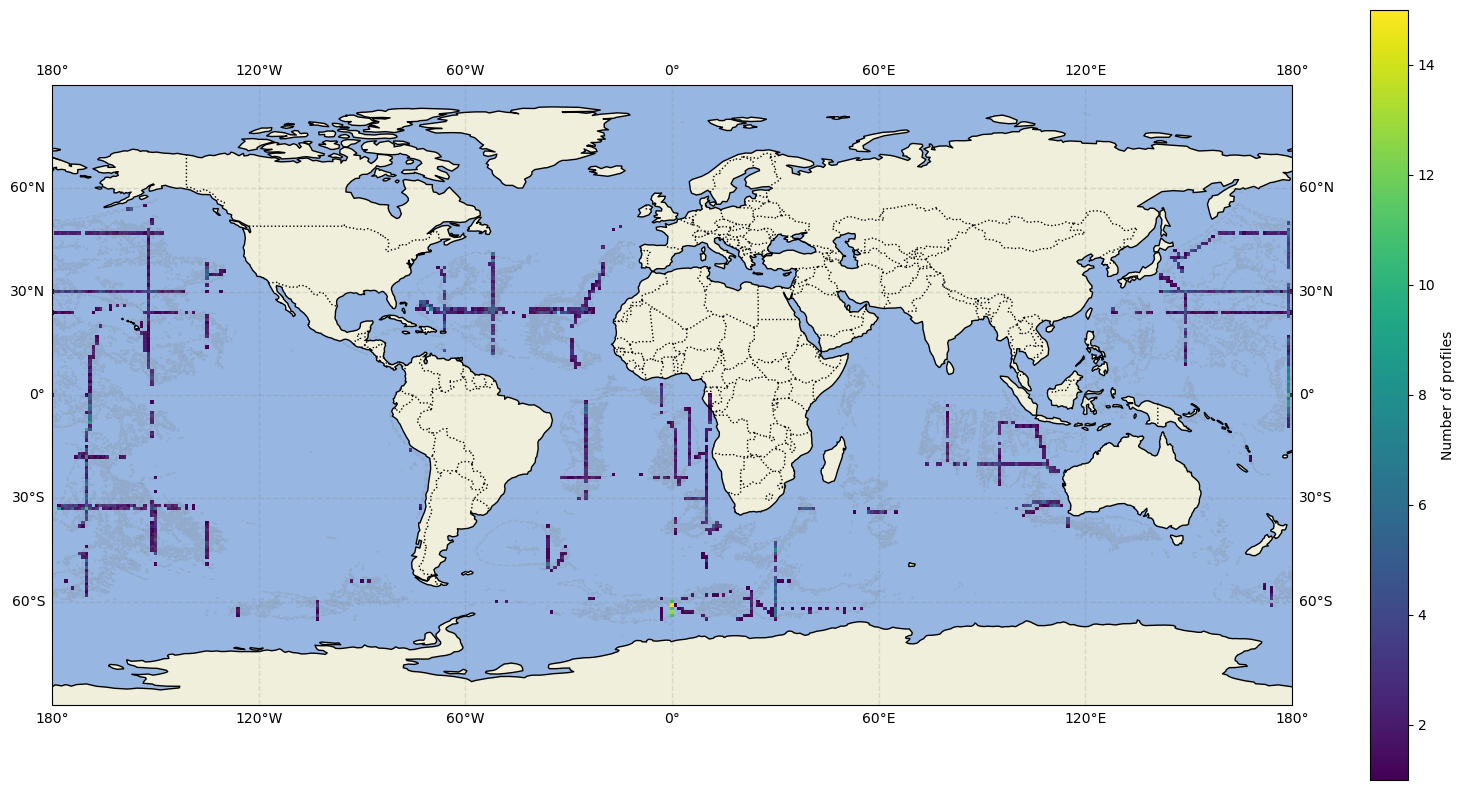

In [15]:
fig = plt.figure(figsize = (20, 10))
ax = plt.axes(projection = ccrs.PlateCarree(central_longitude=0))
ax.set_extent((-180, 180, -90, 90))
ax.coastlines()
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.BORDERS, linestyle = ":")
bathym = cfeature.NaturalEarthFeature(name='bathymetry_F_5000', scale='10m', category='physical')
ax.add_feature(bathym, facecolor='none', edgecolor='gray', linestyle='dashed', linewidth=1, alpha = 0.2)
ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.2, linestyle='--')
profiles = ds.n.plot(ax = ax, transform = ccrs.PlateCarree(), add_colorbar = False)
fig.colorbar(mappable = profiles, label = "Number of profiles")
#plt.savefig("./Data/profiles.png")

(array([ 21.,  28.,  27.,   5.,   7.,   1.,   5.,  18.,   7.,   8.,   6.,
         14.,  37., 168., 145., 103., 329.,   8.,   3.,   2.,   0.,   7.,
         51.,  94.,  72.,   3.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   1.]),
 array([-0.52589433, -0.40447089, -0.28304746, -0.16162402, -0.04020058,
         0.08122286,  0.2026463 ,  0.32406973,  0.44549317,  0.56691661,
         0.68834005,  0.80976349,  0.93118693,  1.05261036,  1.1740338 ,
         1.29545724,  1.41688068,  1.53830412,  1.65972756,  1.78115099,
         1.90257443,  2.02399787,  2.14542131,  2.26684475,  2.38826819,
         2.50969162,  2.63111506,  2.7525385 ,  2.87396194,  2.99538538,
         3.11680881,  3.23823225,  3.35965569,  3.48107913,  3.60250257,
         3.72392601,  3.84534944,  3.96677288,  4.08819632,  4.20961976,
         4.3310432 ]),
 <BarContainer object of 40 artists>)

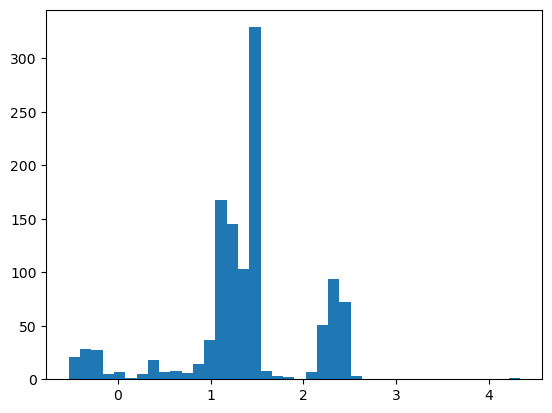

In [16]:
t = ds.sal_means.mean(dim = "depth").values
plt.hist(t.flatten(), bins = 40)